In [1]:
using Pkg
Pkg.activate(".")
Pkg.instantiate()
include("Polyhedron.jl")
using .Poly

  Activating project at `~/Documents/projects/Polyhedron`
┌ Warning: Make sure you comply with the NEOS terms of use: http://www.neos-server.org/neos/termofuse.html
└ @ NEOSServer ~/.julia/packages/NEOSServer/2P7PD/src/NEOSServer.jl:14


In [3]:
A = [0 1;
    -1 0.95] 
B = [0;
     1;;]

C = [0.025 0.025]

T = 0.5

delta = 0.5

A_exp = hcat(A, [0 0; 0 0])
A_exp = vcat(A_exp, [0 -T 1 T; 0 0 0 delta])

B_exp = vcat(B, [0;0])

E_exp = vcat(zeros(3), [1-delta])

Sx = [1/2 0
      0 1/2;
     -1/2 0;
      0 -1/2;]
Sv = [1/10;
      -1/10;]

Sw = [1/10;
      -1/10;]

Sx = vcat(Sx, zeros(4, 2))
Sv = vcat(vcat(zeros(4, 1), Sv) , zeros(2, 1))
Sw = vcat(zeros(6, 1), Sw)

S = hcat(hcat(Sx, Sv), Sw)

# Fr para a referência
R = [1/2;
      -1/2;;]

#testando para d = 1
d = 1

1

In [9]:
result_dis = Poly.finding_L_pinvariant_segref_delay(A_exp, B_exp, E_exp, S, R, d, time=30,lf=16,  lambda=0.999)

Job 18700687 dispatched
password: leNvODMK
---------- Begin Solver Output -----------
Condor submit: 'neos.submit'

Condor submit: 'watchdog.submit'
Job submitted to NEOS HTCondor pool.

OTHER_LIMIT

Dict{String, Matrix{Float64}} with 10 entries:
  "J" => [-1771.27 8358.78 … 6591.11 -5634.82; 1240.48 -4603.45 … -3724.41 2716…
  "M" => [-0.00010692 -8.85676e-5 … -1.5154e-5 -0.000105632; -6.38503e-5 -8.314…
  "P" => [-5.74422e-5 -5.04026e-5; -7.02852e-5 -3.93898e-5; … ; -3.57164e-5 -7.…
  "N" => [-5.39223e-5 -5.39223e-5 … -5.39225e-5 -5.39223e-5; -5.48381e-5 -5.483…
  "T" => [0.0351703 0.964648 … -3.27944e-6 1.06251e-5; -9.52486e-7 2.68956e-7 ……
  "G" => [0.00451634 0.00103036 0.003466 0.00211262]
  "K" => [0.000478842 -0.00739227 -0.000866463 -0.000127068; 0.00397407 -0.0016…
  "L" => [-6.8008e-5 -5.53487e-5 … -5.13625e-5 -6.77024e-5; -8.1608e-5 -5.78311…
  "F" => [0.503646 -0.504739 0.00159033 -2.11169e-5; 0.499933 0.0184218 -6.3159…
  "H" => [-4.93101e-5 1.0024 … -0.000107938 -4.96549e-5; -0.000105554 -4.9143e-…

In [10]:
F = result_dis["F"]
G = result_dis["G"]
K = result_dis["K"]
H = result_dis["H"]
L = result_dis["L"]
M = result_dis["M"]
N = result_dis["N"]
P = result_dis["P"]
T = result_dis["T"]
J = result_dis["J"]

using DelimitedFiles

open("matrices.txt", "w") do f
    println(f, "F")
    writedlm(f, F)
    println(f, "\nG")
    writedlm(f, G)
    println(f, "\nK")
    writedlm(f, K)
    println(f, "\nH")
    writedlm(f, H)
    println(f, "\nL")
    writedlm(f, L)
    println(f, "\nM")
    writedlm(f, M)
    println(f, "\nN")
    writedlm(f, N)
    println(f, "\nP")
    writedlm(f, P)
    println(f, "\nT")
    writedlm(f, T)
    println(f, "\nJ")
    writedlm(f, J)
end

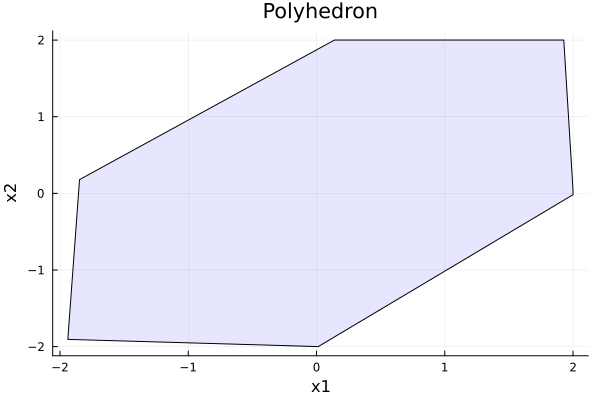

In [14]:
T = Poly.poly_projection(F[:,3:4])
Poly.plot_poly(T*F[:,1:2], T*ones(16))

In [15]:
w = ones(size(F, 1))
nx = size(A_exp, 1)

passos = 100
r = ones(passos) # x2 ir para 1 

BG = B_exp * G

init_cond_F, init_cond_w = Poly.admissable_initCond(A_exp, BG, F, d, w; fixed_d=true)
ext_vertices_tuple = Poly.get_extVert_tuple(init_cond_F, init_cond_w, 2, nx)
traj1 = Poly.trajectory_segref_delay(ext_vertices_tuple, A_exp, BG, E_exp, r, passos, d; reverse=true)

101-element Vector{Tuple}:
 (-1.8472534943323504, 0.18023757617584893, 10.009577800378986, -0.2043908037045929)
 (0.18023757617584893, 1.9999307278556213, 9.817263610438765, 0.3978045981477035)
 (1.9999307278556213, 1.7458008558534714, 9.016200545584805, 0.6989022990738518)
 (1.7458008558534714, -0.3036782535569021, 8.492751267194995, 0.8494511495369259)
 (-0.3036782535569021, -1.9907374045040185, 9.06931596874191, 0.924725574768463)
 (-1.9907374045040185, -1.5487201392972862, 10.52704745837815, 0.9623627873842315)
 (-1.5487201392972862, 0.5494183965425646, 11.782588921718908, 0.9811813936921158)
 (0.5494183965425646, 2.0986008495290838, 11.998470420293684, 0.9905906968460578)
 (2.0986008495290838, 1.4807352324857208, 11.44446534395217, 0.9952953484230289)
 (1.4807352324857208, -0.6435793193519626, 11.201745401920824, 0.9976476742115145)
 (-0.6435793193519626, -2.039362755714496, 12.022358898702564, 0.9988238371057572)
 (-2.039362755714496, -1.2468580568875833, 13.54145219511269, 0.999

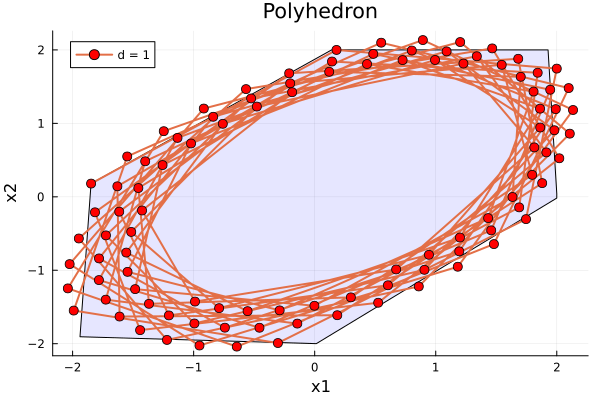

In [16]:
using Plots

T = Poly.poly_projection(F[:,3:4])
Poly.plot_poly(T*F[:,1:2], T*ones(16))

x1 = [p[1] for p in traj1]
x2 = [p[2] for p in traj1]
v = [p[3] for p in traj1]
w = [p[4] for p in traj1]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 1",
     xlabel = "x1",
     ylabel = "x2")
     


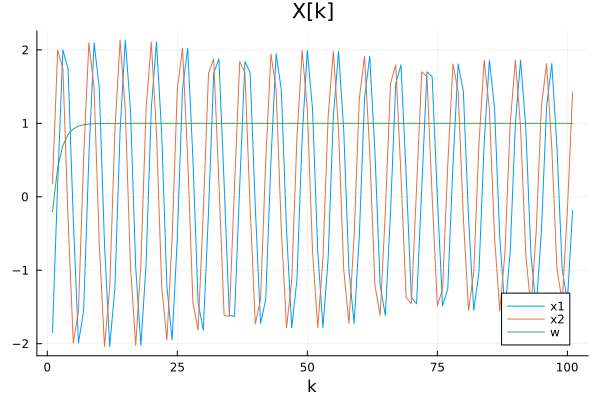

In [17]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")